Exploring UDFs in 2D

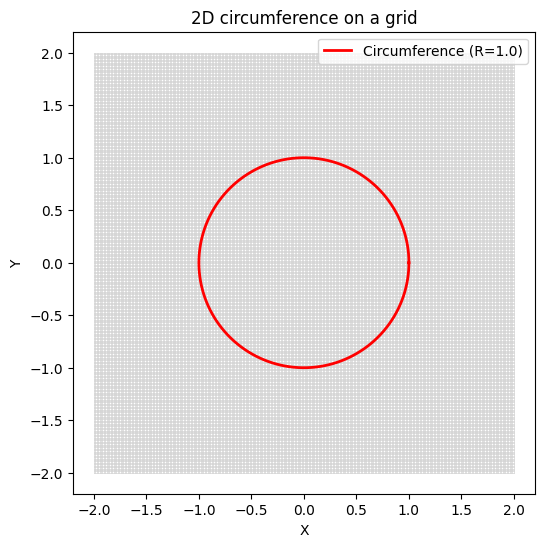

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.grid"] = False

# Create a grid
N = 300
x = np.linspace(-2.0, 2.0, N)
y = np.linspace(-2.0, 2.0, N)
X, Y = np.meshgrid(x, y)
P = np.stack([X, Y], axis=-1)

# Create 2D circumference points
R = 1.0
theta = np.linspace(0, 2 * np.pi, 600)
surface_x = R * np.cos(theta)
surface_y = R * np.sin(theta)

# Plot the grid and the circumference
fig, ax = plt.subplots()

# Draw the vertical lines of the grid P
for i in range(0, N):
    ax.plot(P[:, i, 0], P[:, i, 1], color='lightgray', linewidth=0.5)

# Draw the horizontal lines of the grid P
for i in range(0, N):
    ax.plot(P[i, :, 0], P[i, :, 1], color='lightgray', linewidth=0.5)

# Draw the circumference
ax.plot(surface_x, surface_y, color='red', linewidth=2, label=f'Circumference (R={R})')

ax.set_aspect('equal') 
ax.set_title("2D circumference on a grid")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()

plt.show()

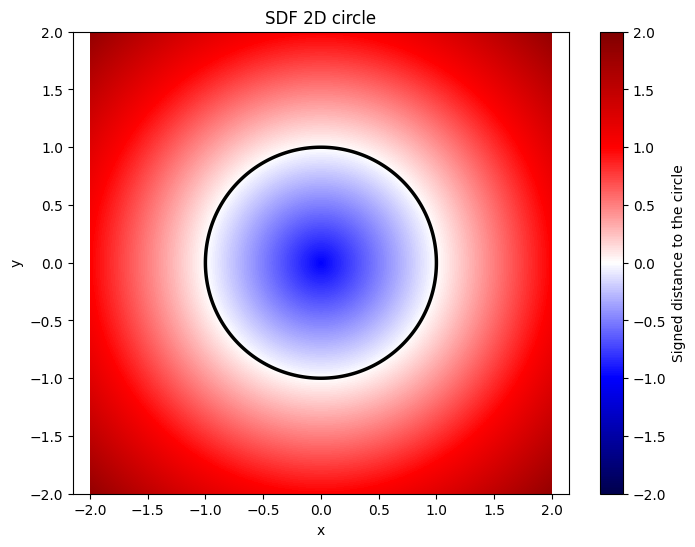

In [2]:
# Distance from points to the circumference: ||p|| = sqrt(x² + y²)
# Define circle surface: ||p|| = R
# sdf(p) = ||p|| - R (if p is on the surface, sdf(p)=0)
# sdf(p) < 0 if p is inside the circle 
# sdf(p) > 0 if p is outside the circle

def sdf_circle(X, Y, R):
    return np.sqrt(X**2 + Y**2) - R

SDF = sdf_circle(X, Y, R)

fig, ax = plt.subplots(figsize=(8, 6)) 


im0 = ax.imshow(
    SDF,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="seismic", 
    vmin=-2, vmax=2
)

ax.contour(X, Y, SDF, levels=[0], colors="black", linewidths=2.5)
ax.set_title("SDF 2D circle")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
plt.colorbar(im0, ax=ax, label="Signed distance to the circle")

plt.show()

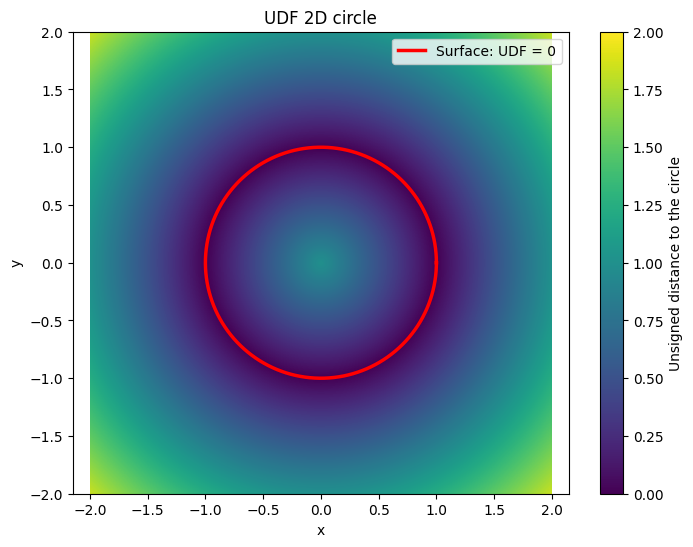

In [3]:
# UDF represents the unsigned distance to the surface.
# It does not distinguish between inside and outside,
# so it is always non-negative.

def udf_circle(X, Y, R):
    return np.abs(np.sqrt(X**2 + Y**2) - R)

UDF = udf_circle(X, Y, R)

fig, ax = plt.subplots(figsize=(8, 6))

im1 = ax.imshow(
    UDF,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=2
)

# For UDF, contour at level 0 may be numerically unstable,
# because UDF only touches zero at the surface.
# Therefore, we plot the analytical surface directly.
ax.plot(
    surface_x,
    surface_y,
    color="red",
    linewidth=2.5,
    label="Surface: UDF = 0"
)

ax.set_title("UDF 2D circle")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.legend()

plt.colorbar(im1, ax=ax, label="Unsigned distance to the circle")

plt.show()

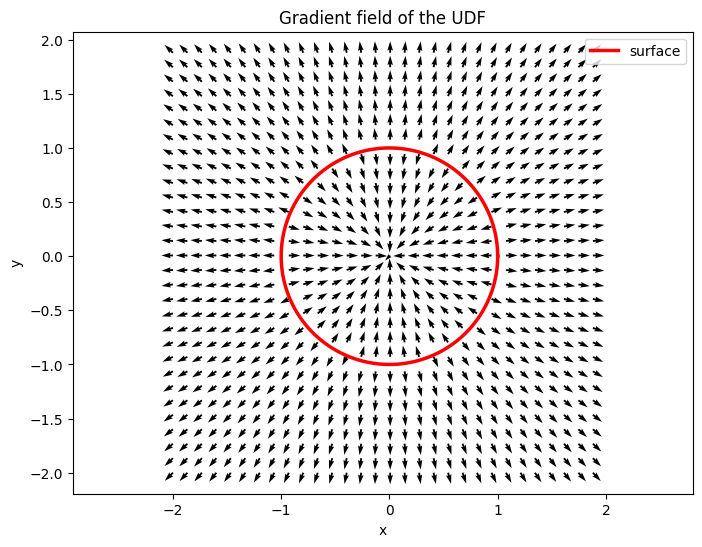

In [4]:
# The gradient points in the direction of maximum increase of the function
# Since UDF measures distance to the surface: grad UDF points toward increasing distance
# Outside the circle, it points outward.
# Inside the circle, it points inward.
# This creates a direction flip at the surface.

dU_dy, dU_dx = np.gradient(UDF)

grad_norm = np.sqrt(dU_dx**2 + dU_dy**2)

fig, ax = plt.subplots(figsize=(8, 6))

step = 10

# ax.quiver(x_start, y_start, x_direction, y_direction)
ax.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    dU_dx[::step, ::step],
    dU_dy[::step, ::step],
    width=0.003
)

ax.plot(
    surface_x,
    surface_y,
    color="red",
    linewidth=2.5,
    label="surface"
)

ax.set_title("Gradient field of the UDF")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.axis("equal")
ax.legend()

plt.show()